In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv(
    "/content/global_reuse_effectiveness.csv"
)

df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour,reuse_efficiency_pct,estimated_reused_water_m3_year,reuse_effectiveness_class,untapped_reuse_m3_year
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06,33.090509,1.241707e+10,Moderate,2.510750e+10
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06,76.303573,1.943447e+10,Highly Effective,6.035463e+09
2,Arab World,ARB,482105978,24105298900,2.751746e+06,59.899546,1.443896e+10,Good,9.666334e+09
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04,49.899386,1.127702e+08,Good,1.132250e+08
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05,16.701398,8.366040e+08,Low,4.172581e+09


In [4]:
features = [
    "population",
    "estimated_greywater_m3_year",
    "greywater_tons_per_hour",
    "reuse_efficiency_pct"
]

X = df[features]

y = df["reuse_effectiveness_class"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
predictions = model.predict(X_test)

In [8]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Model Accuracy:")
print(accuracy)

Model Accuracy:
1.0


In [9]:
print(
    classification_report(
        y_test,
        predictions
    )
)

                  precision    recall  f1-score   support

            Good       1.00      1.00      1.00        15
Highly Effective       1.00      1.00      1.00        14
             Low       1.00      1.00      1.00        12
        Moderate       1.00      1.00      1.00        10

        accuracy                           1.00        51
       macro avg       1.00      1.00      1.00        51
    weighted avg       1.00      1.00      1.00        51



In [10]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df

,feature,importance
3,reuse_efficiency_pct,0.891258
2,greywater_tons_per_hour,0.038134
1,estimated_greywater_m3_year,0.036260
0,population,0.034347


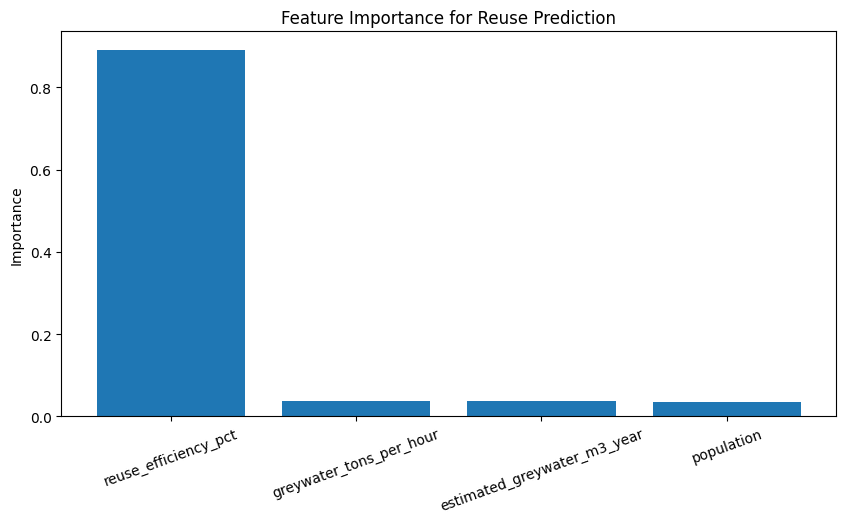

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.title(
    "Feature Importance for Reuse Prediction"
)

plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.show()

In [12]:
df["predicted_reuse_class"] = model.predict(X)

df.to_csv(
    "global_ml_predictions.csv",
    index=False
)

print("Predictions saved.")

Predictions saved.
